In [22]:
# 1 - SVD Realization
import numpy as np


def custom_svd(a):
    ata = np.dot(np.transpose(a), a)
    aat = np.dot(a, np.transpose(a))
    eval_v, v = np.linalg.eig(ata)
    eval_u, u = np.linalg.eig(aat)

    idx_v = np.argsort(eval_v)[::-1]
    eval_v = eval_v[idx_v]
    vt = np.transpose(v[:, idx_v])
    idx_u = np.argsort(eval_u)[::-1]
    eval_u = eval_u[idx_u]
    u = u[:, idx_u]
    
    if a.shape[0] > a.shape[1]:
        sigma_val = np.sqrt(np.absolute(eval_v))
    else:
        sigma_val = np.sqrt(np.absolute(eval_u))
    sigma_mat = np.zeros(a.shape)
    sigma_mat[:min(a.shape), :min(a.shape)] = np.diag(sigma_val)
    return u, sigma_mat, vt

In [23]:
matrix = np.array([[3, 2], [2, 3],])
# matrix = np.array([[-3, 5], [2, -1], [1, -2]])
# matrix = np.array([[3, -2, 2], [2, 3, -2],])
u_matrix, sigma_matrix, vt_matrix = custom_svd(matrix)

print("U:\n", u_matrix)
print("Sigma:\n", sigma_matrix)
print("V^T:\n", vt_matrix)
a_re = np.dot(u_matrix, np.dot(sigma_matrix, vt_matrix))
print("Rebuilt A:\n", a_re)
print("Initial A:\n", matrix)

U:
 [[ 0.70710678 -0.70710678]
 [ 0.70710678  0.70710678]]
Sigma:
 [[5. 0.]
 [0. 1.]]
V^T:
 [[ 0.70710678  0.70710678]
 [-0.70710678  0.70710678]]
Rebuilt A:
 [[3. 2.]
 [2. 3.]]
Initial A:
 [[3 2]
 [2 3]]


In [24]:
# 2.1 - Recommendations Algorithm
import pandas as pd
import matplotlib.pyplot as plt
from scipy.sparse.linalg import svds

df = pd.read_csv('C:/Users/MB_6489/Desktop/ratings.csv')
ratings_matrix = df.pivot(index='userId', columns='movieId', values='rating')


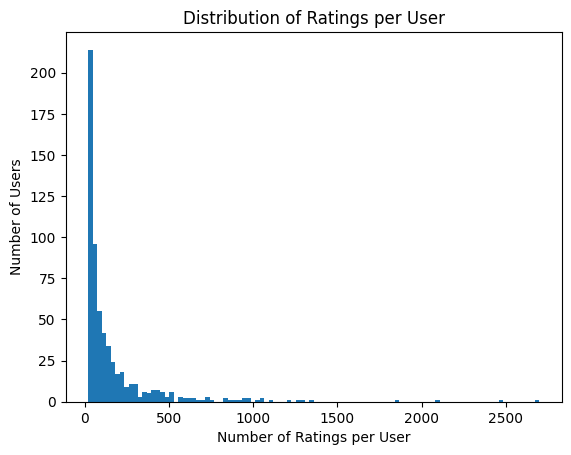

In [25]:
plt.figure()
ratings_per_user = ratings_matrix.notna().sum(axis=1)
plt.hist(ratings_per_user, bins=100)
plt.xlabel('Number of Ratings per User')
plt.ylabel('Number of Users')
plt.title('Distribution of Ratings per User')
plt.show()


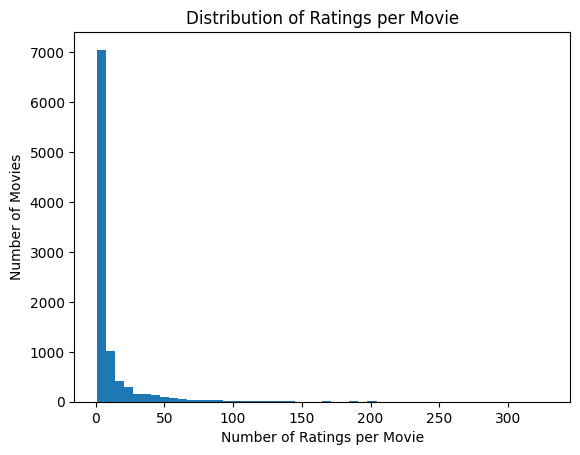

In [26]:
plt.figure()
ratings_per_movie = ratings_matrix.notna().sum(axis=0)
plt.hist(ratings_per_movie, bins=50)
plt.xlabel('Number of Ratings per Movie')
plt.ylabel('Number of Movies')
plt.title('Distribution of Ratings per Movie')
plt.show()

In [27]:
ratings_matrix_ = ratings_matrix.dropna(thresh=50, axis=0)
ratings_matrix_ = ratings_matrix_.dropna(thresh=10, axis=1)
# ratings_matrix_.info()

In [28]:
ratings_matrix_filled = ratings_matrix_.fillna(2.5)
R = ratings_matrix_filled.values
user_ratings_mean = np.mean(R, axis=1)
R_demeaned = R - user_ratings_mean.reshape(-1, 1)
# R_demeaned

In [29]:
U, sigma, Vt = svds(R_demeaned, k=3)

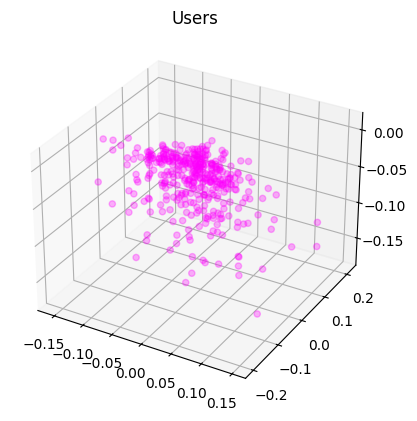

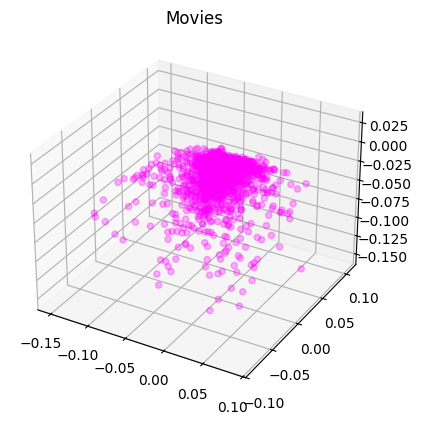

In [30]:
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
ax.scatter(U[:, 0], U[:, 1], U[:, 2], c='magenta', alpha=0.3)
ax.set_title('Users')
plt.show()

fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
ax.scatter(Vt[0, :], Vt[1, :], Vt[2, :], c='magenta', alpha=0.3)
ax.set_title('Movies')
plt.show()


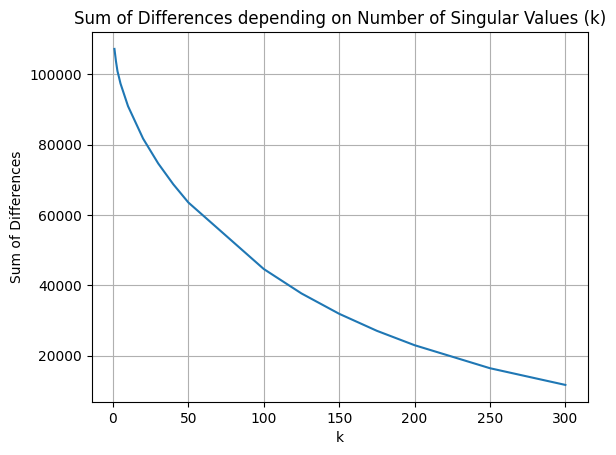

In [31]:
# 2.2 - Recommendations Algorithm Creation
def compute_sum_of_differences(ratings_mat, k):
    ratings_mat_filled = ratings_mat.fillna(2.5)
    r_c = ratings_mat_filled.values

    user_ratings_mean_c = np.mean(r_c, axis=1)
    r_demeaned_c = r_c - user_ratings_mean_c.reshape(-1, 1)
    
    u_c, sigma_c, vt_c = svds(r_demeaned_c, k=k)
    sigma_matrix_c = np.diag(sigma_c)
    
    all_user_predicted_ratings_c = (np.dot(np.dot(u_c, sigma_matrix_c), vt_c) + 
                                    user_ratings_mean_c.reshape(-1, 1))
    
    preds_df_c = pd.DataFrame(all_user_predicted_ratings_c, columns=ratings_mat.columns, index=ratings_mat.index)
    
    diffs = ratings_mat - preds_df_c
    sum_of_differences = diffs.abs().sum().sum()
    return sum_of_differences


k_values = [1, 2, 3, 4, 5, 10, 20, 30, 40, 50, 100, 125, 150, 175, 200, 250, 300]
sum_of_differences_list = []

for i in k_values:
    sum_of_differences_k = compute_sum_of_differences(ratings_matrix, i)
    sum_of_differences_list.append(sum_of_differences_k)

plt.figure()
plt.plot(k_values, sum_of_differences_list)
plt.xlabel('k')
plt.ylabel('Sum of Differences')
plt.title('Sum of Differences depending on Number of Singular Values (k)')
plt.grid(True)
plt.show()

In [32]:
U_2, sigma_2, Vt_2 = svds(R_demeaned, k=50)
sigma_2_matrix = np.diag(sigma_2)
all_user_predicted_ratings = np.dot(np.dot(U_2, sigma_2_matrix), Vt_2) + user_ratings_mean.reshape(-1, 1)
preds_df = pd.DataFrame(all_user_predicted_ratings, columns=ratings_matrix_.columns, 
                         index=ratings_matrix_.index)

diff = ratings_matrix_ - preds_df

preds_df_only = preds_df
preds_df_only[~ratings_matrix_.isna()] = np.nan
preds_df_only

movieId,1,2,3,5,6,7,9,10,11,12,...,159093,164179,166528,168250,168252,174055,176371,177765,179819,187593
userId,,,,,,,,,,,,,,,,,,,,,
1,NaN,2.740370,NaN,2.402930,NaN,2.120664,2.478509,2.606325,2.463224,2.396467,...,2.453868,2.303460,2.824301,2.199890,2.382089,2.464663,2.693503,2.486817,2.609937,2.535007
4,3.193652,2.586381,2.642989,2.486697,2.830139,2.573119,2.517260,2.297585,2.601265,2.377959,...,2.521987,2.768399,2.717455,2.527622,2.546432,2.620083,2.657967,2.466243,2.672766,2.797583
6,3.716216,NaN,NaN,NaN,NaN,NaN,2.727623,NaN,NaN,2.548449,...,2.506715,2.447716,2.430707,2.466707,2.615255,2.538571,2.549658,2.589855,2.619209,2.584622
7,NaN,2.734919,2.523704,2.590331,2.580667,2.576247,2.523752,3.038754,2.565508,2.492235,...,2.473173,2.604675,2.547972,2.477084,2.468283,2.503833,2.441111,2.492352,2.450524,2.500685
10,2.685906,2.553208,2.583743,2.555738,2.525061,2.505339,2.533827,2.852816,2.490544,2.499312,...,2.535230,2.515766,2.503716,2.526173,2.554786,2.627088,2.422785,2.615767,2.597378,2.565718
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
605,NaN,NaN,2.594844,2.679898,2.436624,2.648272,2.574212,2.738189,2.511983,2.497830,...,2.545940,2.538306,2.741346,2.527605,2.613237,2.464047,2.414376,2.596219,2.618406,2.545197
606,NaN,2.351852,2.718316,2.132811,2.150673,NaN,2.425368,2.214040,NaN,2.526818,...,2.183403,2.245838,2.751003,2.240769,2.301603,2.354290,2.406630,2.509198,2.631766,2.314120
607,NaN,2.782942,2.606195,2.390905,2.880003,2.233775,2.470249,2.582876,NaN,2.629233,...,2.455242,2.663718,2.766236,2.611213,2.548717,2.489373,2.567510,2.540226,2.558591,2.586694


In [33]:
movies = pd.read_csv('C:/Users/MB_6489/Desktop/movies.csv')

In [34]:
def get_user_recommended_movies(user, preds_df_only_f, movies_df):
    recs = preds_df_only_f.reset_index()
    user_recs = recs[recs['userId'] == user].transpose()
    user_recs = user_recs.iloc[1:, :].reset_index()
    user_recs.rename(columns={user_recs.columns[1]: 'expected_rating'}, inplace=True)
    top_10_user_recs = user_recs.sort_values(by='expected_rating',ascending=False).head(10)
    top_10_user_recs_ = top_10_user_recs.merge(movies_df, on='movieId', how='left')
    return top_10_user_recs_

In [35]:
get_user_recommended_movies(24, preds_df_only, movies)

,movieId,expected_rating,title,genres
0,527,3.421591,Schindler's List (1993),Drama|War
1,260,3.222912,Star Wars: Episode IV - A New Hope (1977),Action|Adventure|Sci-Fi
2,2959,3.170009,Fight Club (1999),Action|Crime|Drama|Thriller
3,48516,3.131401,"Departed, The (2006)",Crime|Drama|Thriller
4,110,3.099371,Braveheart (1995),Action|Drama|War
5,68954,3.065783,Up (2009),Adventure|Animation|Children|Drama
6,7361,3.052415,Eternal Sunshine of the Spotless Mind (2004),Drama|Romance|Sci-Fi
7,60069,3.045967,WALL·E (2008),Adventure|Animation|Children|Romance|Sci-Fi
8,1270,3.042124,Back to the Future (1985),Adventure|Comedy|Sci-Fi
9,33794,3.034333,Batman Begins (2005),Action|Crime|IMAX
